<a href="https://colab.research.google.com/github/Thanseeh07/Housing-price-prediction/blob/main/mle%20map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

np.random.seed(42)
sns.set_theme(style="whitegrid")

data = load_breast_cancer()
x=pd.DataFrame(data.data, columns=data.feature_names)
y=data.target

print(f"Dataset Shape:{x.shape}")
print(f"Class Distribution:{np.bincount(y)}(0:Malignant,1:Benign)")

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scalar=StandardScaler()
x_train_scaled=scalar.fit_transform(x_train)
x_test_scaled=scalar.transform(x_test)

print("Preprocessing complete.")

Dataset Shape:(569, 30)
Class Distribution:[212 357](0:Malignant,1:Benign)
Preprocessing complete.


In [11]:
mle_model=LogisticRegression(penalty=None,max_iter=10000)
mle_model.fit(x_train_scaled,y_train)

map_l2_model=LogisticRegression(penalty='l2',C=1.0,solver='lbfgs',max_iter=10000)
map_l2_model.fit(x_train_scaled,y_train)

map_l1_model=LogisticRegression(penalty='l1',solver='saga',C=1.0,max_iter=10000)
map_l1_model.fit(x_train_scaled,y_train)

weights_df=pd.DataFrame({
    'Feature':['Intercept'] + list(data.feature_names),
    'MLE':np.insert(mle_model.coef_[0],0,mle_model.intercept_[0]),
    'MAP_L2(Gaussian)':np.insert(map_l2_model.coef_[0],0,map_l2_model.intercept_[0]),
    'MAP_L1(Laplace)':np.insert(map_l1_model.coef_[0],0,map_l1_model.intercept_[0])
})
weights_df.head(10)

,Feature,MLE,MAP_L2(Gaussian),MAP_L1(Laplace)
0,Intercept,-63.532600,0.445585,0.299321
1,mean radius,9.433096,-0.431904,0.000000
2,mean texture,-16.986388,-0.387326,0.000000
3,mean perimeter,40.020926,-0.393432,0.000000
4,mean area,10.890150,-0.465210,0.000000
5,mean smoothness,5.033443,-0.071667,0.000000
6,mean compactness,274.940098,0.540164,0.000000
7,mean concavity,-134.838158,-0.801458,0.000000
8,mean concave points,-266.184736,-1.119804,-2.195998
9,mean symmetry,40.996505,0.236119,0.053600


In [12]:
def evaluate(model,x,y,name):
  preds=model.predict(x)
  probs=model.predict_proba(x)[:,1]
  return{
      'Model':name,
      'Accuracy':accuracy_score(y,preds),
      'Precision':precision_score(y,preds),
      'Recall':recall_score(y,preds),
      'F1 Score':f1_score(y,preds),
      'AUC':roc_auc_score(y,probs)
  }

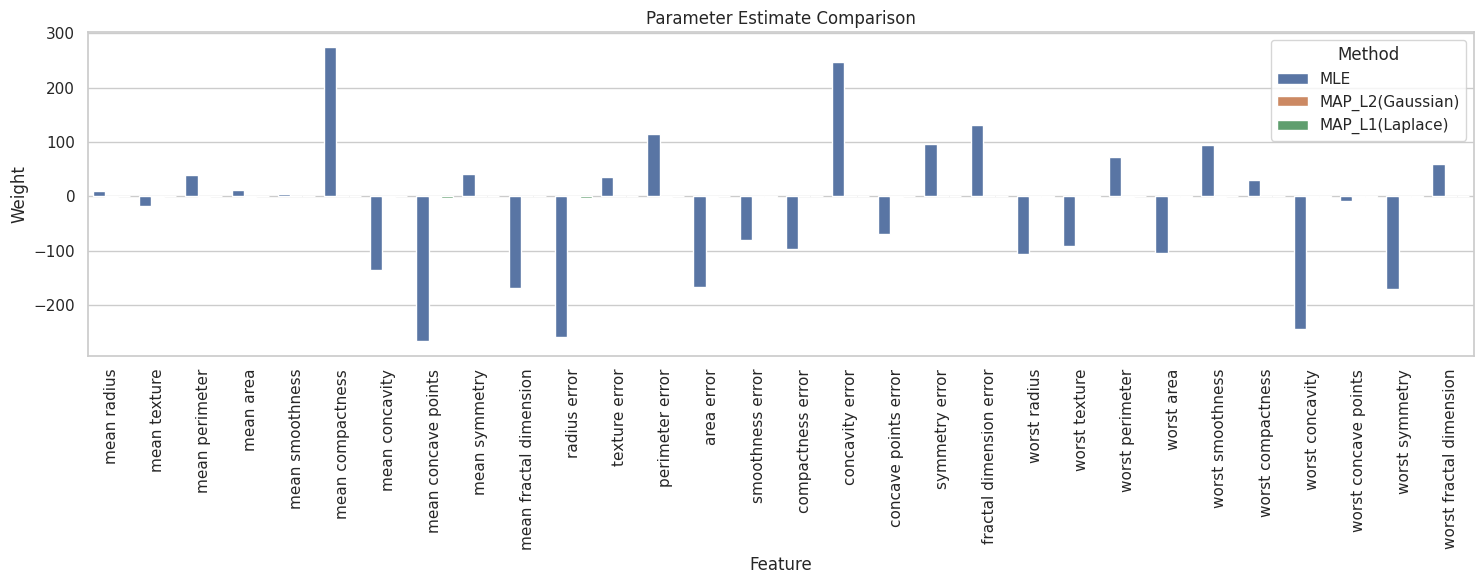

Number of zero weights in L1(Laplace): 15


In [18]:
results=[
    evaluate(mle_model,x_test_scaled,y_test,'MLE(No Regularization)'),
    evaluate(map_l2_model,x_test_scaled,y_test,'MAP(L2 Regularization)'),
    evaluate(map_l1_model,x_test_scaled,y_test,'MAP(L1 Regularization)')
]

pd.DataFrame(results)

plt.figure(figsize=(15,6))
melted_w=weights_df.melt(id_vars='Feature',value_vars=['MLE','MAP_L2(Gaussian)','MAP_L1(Laplace)'],var_name='Method',value_name='Weight')
sns.barplot(data=melted_w[melted_w['Feature']!='Intercept'],x='Feature',y='Weight',hue='Method')
plt.title('Parameter Estimate Comparison')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Number of zero weights in L1(Laplace):",np.sum(map_l1_model.coef_[0]==0))
